# Imports

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import h5py
import static_utils
import pathlib
import pandas as pd
import seaborn as sns
from scipy import stats

%matplotlib inline

In [2]:
%pwd

'/home/lbiswas/Code/gh-prep/mr-tracking-tests-arjun/Static_Tracking'

# Constants and Paths

In [3]:
# Main data paths for each catheter (manually input)
prepend = '/data' # Change to empty string after zenodo get
parent_path = prepend + '/processed'
if (not os.path.isdir(parent_path)):
    print("Using precomputed outputs")
    parent_path = '../data/preprocessed'

class YLoc:
    def __init__(self, description=None, input_path_suffix=None, export_path_suffix=None):
        self.description = description
        self.in_suffix = input_path_suffix
        self.out_suffix = export_path_suffix
        
y_locations = [YLoc('Y = 45mm','Y0','Y45mm'), YLoc('Y = 20mm','Y1', 'Y20mm'), YLoc('Y = -5mm', 'Y2', 'Y-5mm')]
catheter_labels = ['C222','C231','C306']

main_paths = {} # input coordinate data from each catheter and position
heatmap_paths = {} # exported heatmap plots
xpmt_date_dict = {
    (catheter_labels[0],'Y0'):'17Aug2021',
    (catheter_labels[1],'Y0'):'15Dec2021',
    (catheter_labels[2],'Y0'):'13Dec2021',
    (catheter_labels[0],'Y1'):'8Nov2021',
    (catheter_labels[1],'Y1'):'21Dec2021',
    (catheter_labels[2],'Y1'):'6Jan2022',
    (catheter_labels[0],'Y2'):'9Nov2021',
    (catheter_labels[1],'Y2'):'9Jan2022',
    (catheter_labels[2],'Y2'):'7Jan2022',
}
for yloc in y_locations:
    main_paths[yloc.in_suffix] = []
    for cath in catheter_labels:
        xpmt_date = xpmt_date_dict[(cath,yloc.in_suffix)]
        main_paths[yloc.in_suffix].append(f'{parent_path}/static/trackTest-{xpmt_date}-{cath}-{yloc.in_suffix}/')
    heatmap_paths[yloc.in_suffix] = f'../reports/figures/static/{yloc.out_suffix}/'
        
#main_path_222 = parent_path + '/static/trackTest-17Aug2021-C222-Y0/'
#main_path_231 = parent_path + '/static/trackTest-15Dec2021-C231-Y0/'
#main_path_306 = parent_path + '/static/trackTest-13Dec2021-C306-Y0/'

#main_path = [main_path_222, main_path_231, main_path_306]

# Where you would like to save the heatmaps (manually input)
#heatmap_path = '../reports/figures/static/Y45mm/'

# Tip error data is also exported to HDF5 files
error_path = '../reports/export/static/'

Gt_filename = '1GroundTruthCoords.csv'

geometry_index = 1

Using precomputed outputs


In [4]:
def get_catheter_from_path(path):
    for c in catheter_labels:
        if c in path:
            return c
    return None

# Error Heatmaps

For each sequence and localization algorithm of interest, plot the heatmap of average tip errors at each position. Each position has recordings from three catheters.

Error heatmaps for Y = 45mm
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm centroid_around_peak


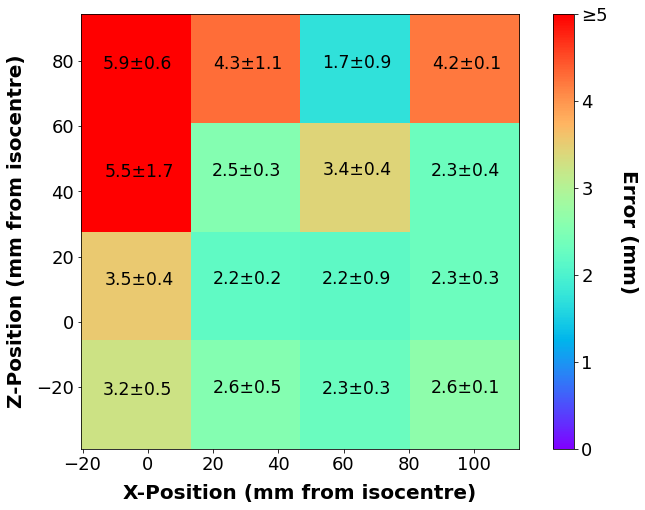

Saving error data from each catheter to: ../reports/export/static/Y0_SRI_Original_centroid_around_peak.h5
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm jpng


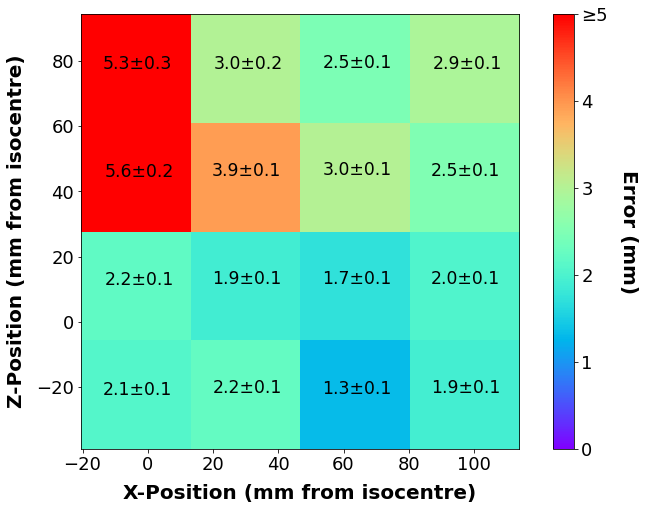

Saving error data from each catheter to: ../reports/export/static/Y0_SRI_Original_jpng.h5
Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


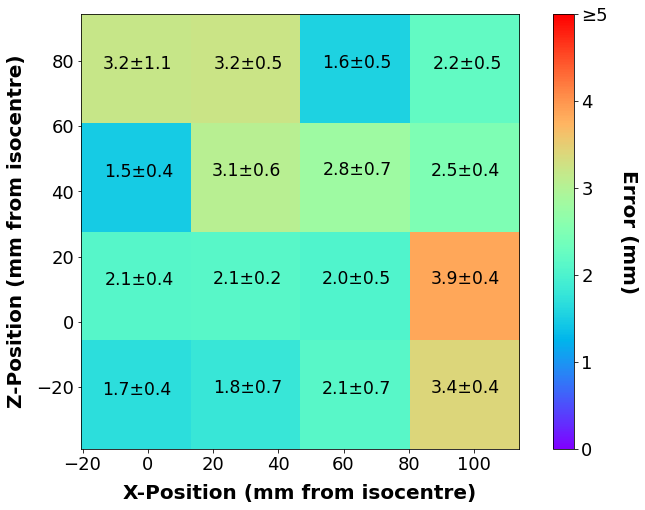

Saving error data from each catheter to: ../reports/export/static/Y0_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm jpng


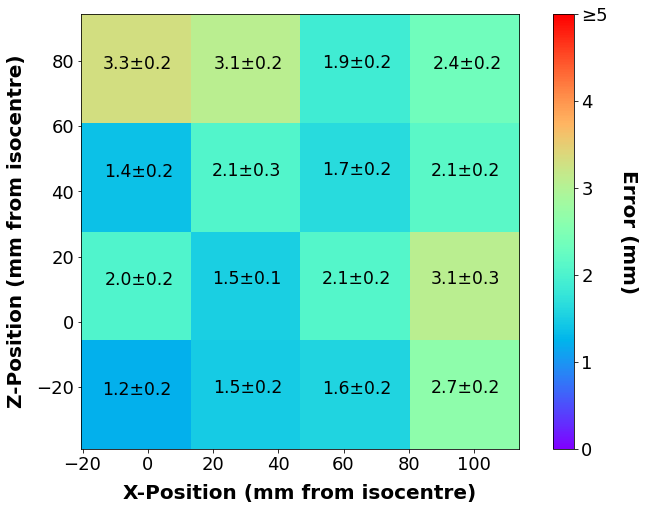

Saving error data from each catheter to: ../reports/export/static/Y0_FH512_noDither_gradSpoiled_jpng.h5
Error heatmaps for Y = 20mm
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm centroid_around_peak


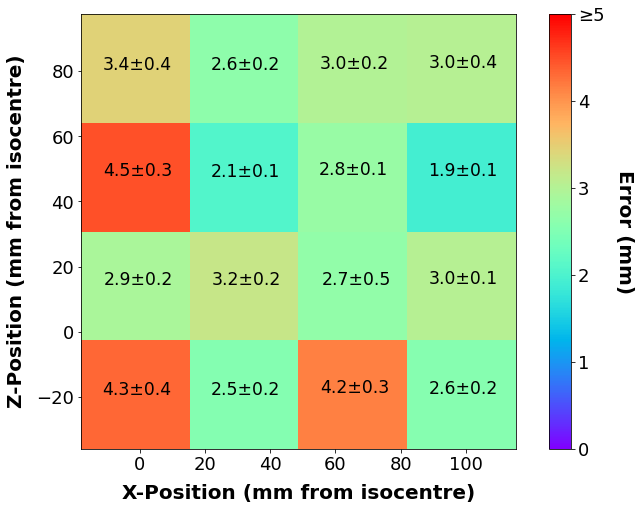

Saving error data from each catheter to: ../reports/export/static/Y1_SRI_Original_centroid_around_peak.h5
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm jpng


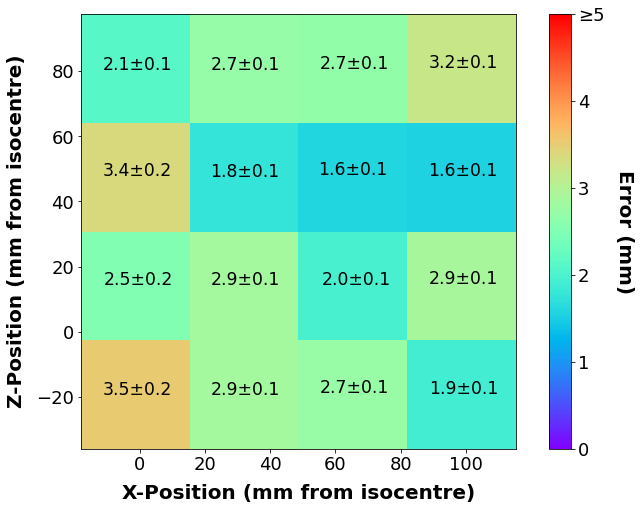

Saving error data from each catheter to: ../reports/export/static/Y1_SRI_Original_jpng.h5
Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


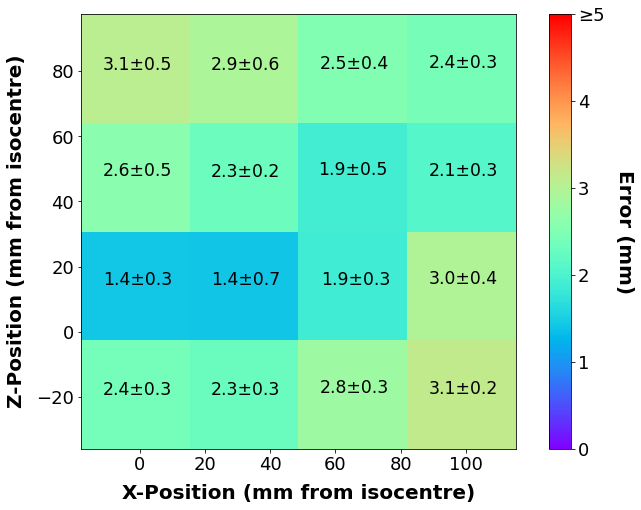

Saving error data from each catheter to: ../reports/export/static/Y1_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm jpng


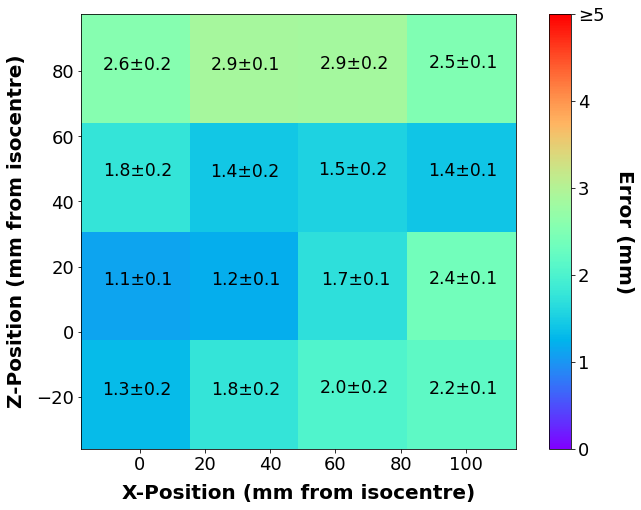

Saving error data from each catheter to: ../reports/export/static/Y1_FH512_noDither_gradSpoiled_jpng.h5
Error heatmaps for Y = -5mm
Adjusting for missing recording for SRI_Original, centroid_around_peak, Y2
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm centroid_around_peak


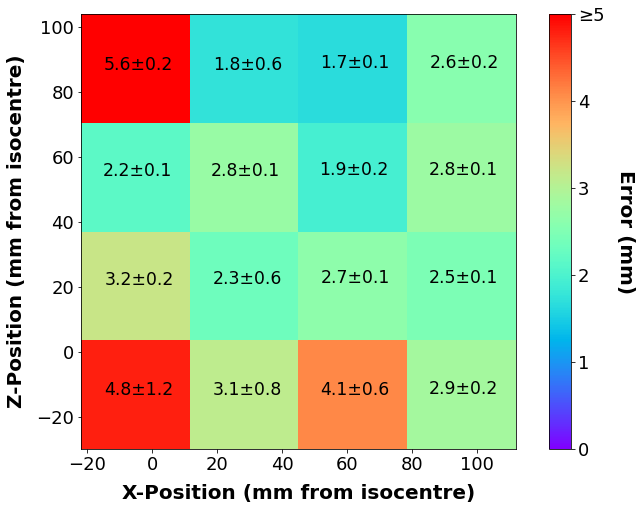

Saving error data from each catheter to: ../reports/export/static/Y2_SRI_Original_centroid_around_peak.h5
Adjusting for missing recording for SRI_Original, jpng, Y2
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm jpng


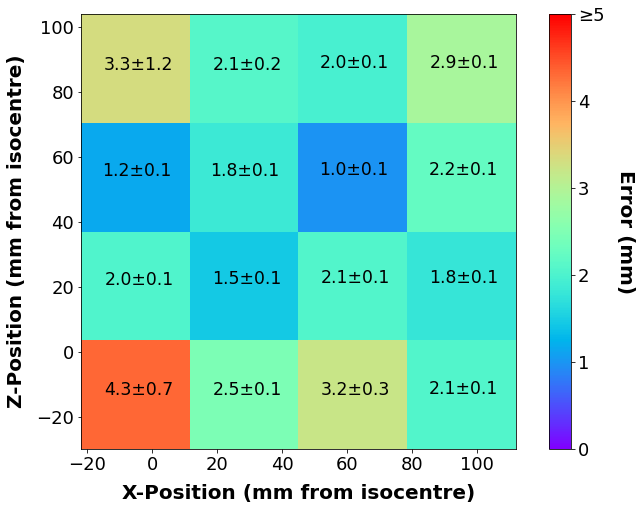

Saving error data from each catheter to: ../reports/export/static/Y2_SRI_Original_jpng.h5
Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


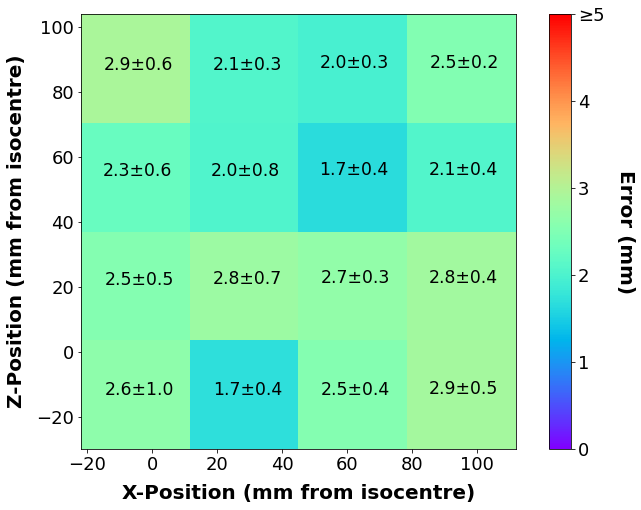

Saving error data from each catheter to: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm jpng


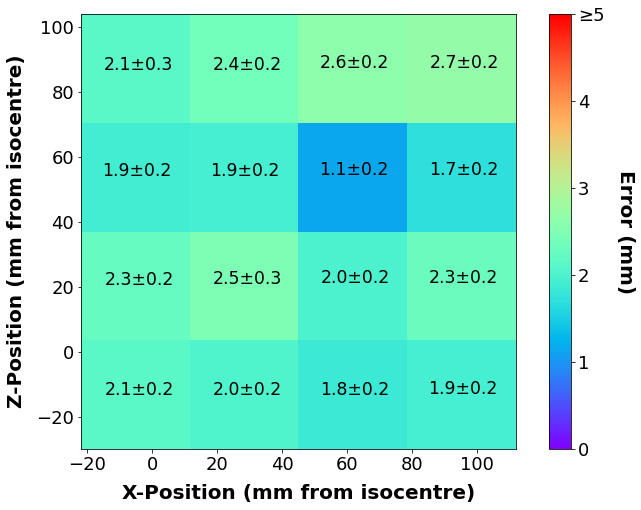

Saving error data from each catheter to: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_jpng.h5


In [5]:
sequences = ['SRI_Original', 'FH512_noDither_gradSpoiled']
algorithms = ['centroid_around_peak', 'jpng']
aggregate_data = []

os.makedirs(error_path, exist_ok=True)

for yloc in y_locations:
    print(f'Error heatmaps for {yloc.description}')
    for seq in sequences:
        for alg in algorithms:
            main_path = main_paths[yloc.in_suffix]
            path_dct = static_utils.get_catheter_data(main_path, seq, alg, Gt_filename, geometry_index)
            # Aggregate
            for path in main_path: # path per catheter
                cath_label = get_catheter_from_path(path)
                coord_stats = path_dct[path][0]
                coord_biases = path_dct[path][1]
                for loc in range(16): # for each grid location
                    bias = coord_stats[loc][2]
                    variance =  coord_stats[loc][3]
                    count = coord_stats[loc][4]
                    aggregate_data.append({'Y_Loc': yloc.in_suffix, 'Sequence':seq, 'Algorithm': alg, 'Catheter':cath_label, \
                             'Grid_Loc':loc+1, 'Mean_Bias':bias, 'Biases':coord_biases[loc], 'Variance':variance, 'Count':count})
            # Average the error over catheters
            sum_all_caths = path_dct[main_path[0]][0] + path_dct[main_path[1]][0] + path_dct[main_path[2]][0]
            avg_all_caths = sum_all_caths / 3
            if seq == 'SRI_Original' and yloc.in_suffix == 'Y2':
                # A recording is missing - results in one invalid 0 mm error in the path_dct
                print(f'Adjusting for missing recording for {seq}, {alg}, {yloc.in_suffix}')
                avg_all_caths[1, 2] = avg_all_caths[1, 2] * 3/2.0 # recover total sum, then divide by 2 for mean
            avg_err = avg_all_caths[:, 2]
            stddev = np.sqrt(sum_all_caths[:, 3])


            my_data = np.array([avg_all_caths[:, 0], avg_all_caths[:, 1], avg_err]).T

            X = my_data[:, 0]
            Y = my_data[:, 1]
            Z = my_data[:, 2]

            heatmap = static_utils.nonuniform_imshow(X, Y, Z, stddev, numeric=True)
            plt.gca().invert_yaxis()
            plt.xlabel('X-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
            plt.ylabel('Z-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
            plt.xticks(fontsize = 18)
            plt.yticks(fontsize = 18)
            print('Tip Tracking Error @ {2} sequence {0}, algorithm {1}'.format(seq, alg, yloc.description))
            cbar = plt.colorbar(heatmap)
            cbar.ax.set_yticklabels(['0', '1', '2', '3', '4', '\u2265' + '5'])
            cbar.ax.get_yaxis().labelpad = 30
            cbar.ax.tick_params(labelsize = 18)
            cbar.ax.set_ylabel('Error (mm)', rotation = 270, fontsize = 20, fontweight = 'bold')

            if not os.path.isdir('{0}'.format(heatmap_paths[yloc.in_suffix])):
                os.makedirs('{0}'.format(heatmap_paths[yloc.in_suffix]))

            plt.savefig('{0}{1}_{2}_heatmap.png'.format(heatmap_paths[yloc.in_suffix], seq, alg), dpi=300)
            plt.show()
            # Below we save the tip errors from each catheter to hdf5 format
            h5out = '{0}{3}_{1}_{2}.h5'.format(error_path, seq, alg, yloc.in_suffix)
            with h5py.File(h5out, 'w', libver='latest') as f:
                print("Saving error data from each catheter to: " + h5out)
                for k, v in path_dct.items():
                    expmt = pathlib.PurePath(k).parts[-1]
                    name = 'static_err_' + seq + '_' + alg + '_' + expmt
                    f.create_dataset(name, data=v[0])

# Comparisons across Sequences and Algorithms
We plan to compare tip errors from the JPNG and CAP peak-finding algorithms, for each sequence. Then we will compare tip errrors from both the HM & 3P sequences, with both JPNG and CAP algorithms. This will result in four comparisons, so we will use a Bonferroni adjustment for the p-value.

In [6]:
p_val_adj = 0.05 / 4

In [7]:
p_val_adj

0.0125

In [8]:
agg_df = pd.DataFrame(aggregate_data)

In [9]:
agg_df

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count
0,Y0,SRI_Original,centroid_around_peak,C222,1,2.008767,"[1.9833520602399075, 2.0714497764852036, 1.812...",0.004414,337.0
1,Y0,SRI_Original,centroid_around_peak,C222,2,3.191142,"[3.090043110615727, 3.126779341178156, 3.09207...",0.003175,339.0
2,Y0,SRI_Original,centroid_around_peak,C222,3,0.943139,"[1.1408342182641895, 0.9749383302433562, 1.095...",0.095942,346.0
3,Y0,SRI_Original,centroid_around_peak,C222,4,2.860096,"[2.925006311464213, 2.7307822863905487, 2.9305...",0.002472,340.0
4,Y0,SRI_Original,centroid_around_peak,C222,5,2.723867,"[2.7734128719347777, 2.6661149919671536, 2.653...",0.003099,356.0
...,...,...,...,...,...,...,...,...,...
571,Y2,FH512_noDither_gradSpoiled,jpng,C306,12,1.976280,"[2.0967337921131093, 2.098694082491882, 2.1577...",0.003945,177.0
572,Y2,FH512_noDither_gradSpoiled,jpng,C306,13,1.635469,"[1.7734196051076967, 1.7106319403999157, 1.726...",0.005249,182.0
573,Y2,FH512_noDither_gradSpoiled,jpng,C306,14,1.927978,"[2.0415259202574005, 2.3109337099813385, 2.288...",0.010374,179.0
574,Y2,FH512_noDither_gradSpoiled,jpng,C306,15,1.885135,"[2.0088087950072353, 2.0332241908185344, 2.152...",0.005632,180.0


In [10]:
agg_df[agg_df['Count']==0] # Missed recording from a sequence at one grid location

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count
417,Y2,SRI_Original,centroid_around_peak,C306,2,0.0,[],0.0,0.0
465,Y2,SRI_Original,jpng,C306,2,0.0,[],0.0,0.0


In [11]:
# Missing recording for this combination!
#invalid_rows = agg_df[(agg_df['Y_Loc']=='Y2') & (agg_df['Sequence']=='SRI_Original') & (agg_df['Catheter']=='C306') & (agg_df['Grid_Loc']==2)].index

In [12]:
agg_df = agg_df.drop(agg_df[agg_df['Count']==0].index)

In [13]:
agg_df[agg_df['Count']==0]

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count


In [14]:
agg_df  # each row contains the error (bias) and variance for one multi-second recording
        # of one sequence, from one catheter, at one location, processed with one algorithm

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count
0,Y0,SRI_Original,centroid_around_peak,C222,1,2.008767,"[1.9833520602399075, 2.0714497764852036, 1.812...",0.004414,337.0
1,Y0,SRI_Original,centroid_around_peak,C222,2,3.191142,"[3.090043110615727, 3.126779341178156, 3.09207...",0.003175,339.0
2,Y0,SRI_Original,centroid_around_peak,C222,3,0.943139,"[1.1408342182641895, 0.9749383302433562, 1.095...",0.095942,346.0
3,Y0,SRI_Original,centroid_around_peak,C222,4,2.860096,"[2.925006311464213, 2.7307822863905487, 2.9305...",0.002472,340.0
4,Y0,SRI_Original,centroid_around_peak,C222,5,2.723867,"[2.7734128719347777, 2.6661149919671536, 2.653...",0.003099,356.0
...,...,...,...,...,...,...,...,...,...
571,Y2,FH512_noDither_gradSpoiled,jpng,C306,12,1.976280,"[2.0967337921131093, 2.098694082491882, 2.1577...",0.003945,177.0
572,Y2,FH512_noDither_gradSpoiled,jpng,C306,13,1.635469,"[1.7734196051076967, 1.7106319403999157, 1.726...",0.005249,182.0
573,Y2,FH512_noDither_gradSpoiled,jpng,C306,14,1.927978,"[2.0415259202574005, 2.3109337099813385, 2.288...",0.010374,179.0
574,Y2,FH512_noDither_gradSpoiled,jpng,C306,15,1.885135,"[2.0088087950072353, 2.0332241908185344, 2.152...",0.005632,180.0


## JPNG vs CAP
### HM
Compare JPNG and CAP algorithms in the hadamard-multiplexed sequence

In [15]:
hm_df = agg_df[agg_df['Sequence']=='FH512_noDither_gradSpoiled']

In [16]:
hm_cap_errors = hm_df[hm_df['Algorithm']=='centroid_around_peak']['Biases'].apply(pd.Series).values.ravel()

In [17]:
hm_cap_errors

array([0.73024172, 0.75007554, 0.92962969, ...,        nan,        nan,
              nan])

In [18]:
hm_jpng_errors = hm_df[hm_df['Algorithm']=='jpng']['Biases'].apply(pd.Series).values.ravel()

In [19]:
hm_jpng_errors

array([0.51057485, 0.68020348, 0.65147419, ...,        nan,        nan,
              nan])

In [20]:
np.isnan(hm_jpng_errors).sum() / len(hm_jpng_errors)

0.0386850845410628

In [21]:
np.array_equal(np.isnan(hm_jpng_errors),np.isnan(hm_cap_errors))

True

In [22]:
# NaNs in our tip error are likely due to recordings for multiple coils finishing at slightly different times
# They match between the arrays, so remove them
hm_cap_errors = hm_cap_errors[~np.isnan(hm_cap_errors)]
hm_jpng_errors = hm_jpng_errors[~np.isnan(hm_jpng_errors)]

In [23]:
len(hm_cap_errors)

25471

In [24]:
len(hm_jpng_errors)

25471

In [25]:
w, p = stats.wilcoxon(x=hm_jpng_errors,y=hm_cap_errors,alternative='less')

In [26]:
p

0.0

In [27]:
import sys
sys.path.append('../')

In [28]:
import Invivo_Tracking.displacement_utils as disp_utils

/home/lbiswas/miniconda3/envs/mr-track/lib/python3.8/site-packages/scipy/stats/morestats.py:1676: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Static Experiment HM Sequence: CAP vs JPNG Tip Error Wilcoxon one-tailed


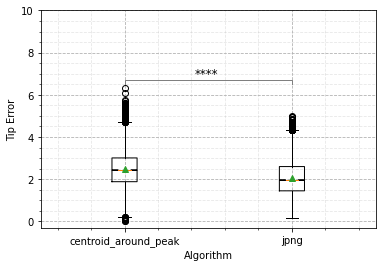

In [29]:
plot, test = disp_utils.plot_displacement_boxplot([hm_cap_errors,hm_jpng_errors], show_scatter=False,\
                                                  y_label='Tip Error',set_ymax=10, p_value=p_val_adj, alternative='greater')
print('Static Experiment HM Sequence: CAP vs JPNG Tip Error '+ test)
plot.savefig('../reports/figures/static/HM-capVsJpng-tipErr.pdf',dpi=600)
plot.show()

#### HM mean bias comparison
Compare JPNG and CAP algorithms in the hadamard-multiplexed sequence, using the mean biases from each 3d grid location - this should be an average of the biases from each catheter:

In [30]:
hm_cap_mean_errors = hm_df[hm_df['Algorithm']=='centroid_around_peak']['Mean_Bias'].values

In [31]:
hm_jpng_mean_errors = hm_df[hm_df['Algorithm']=='jpng']['Mean_Bias'].values

In [32]:
len(hm_cap_mean_errors)

144

In [33]:
len(hm_jpng_mean_errors)

144

In [34]:
hm_cap_mean_errors = []
hm_jpng_mean_errors = []

In [35]:
hm_df[(hm_df['Algorithm']=='centroid_around_peak') & (hm_df['Y_Loc']=='Y0') & (hm_df['Grid_Loc']==1)]

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count
96,Y0,FH512_noDither_gradSpoiled,centroid_around_peak,C222,1,1.137697,"[0.7302417240937265, 0.7500755356069915, 0.929...",0.015660,181.0
112,Y0,FH512_noDither_gradSpoiled,centroid_around_peak,C231,1,1.844296,"[1.011415294950236, 1.7755828482800864, 1.6729...",0.027717,183.0
128,Y0,FH512_noDither_gradSpoiled,centroid_around_peak,C306,1,2.110798,"[1.4787031727265678, 1.0285377346011988, 1.376...",0.111438,184.0


In [36]:
y_locs = hm_df['Y_Loc'].unique() # unique(): returned in order of appearance

In [37]:
grid_locs = hm_df['Grid_Loc'].unique()

When comparing the two algorithms, the number of samples is the same, so we can average the Mean_Bias column

In [38]:
for y in y_locs:
    for g in grid_locs:
        cap_mean = hm_df[(hm_df['Algorithm']=='centroid_around_peak') & (hm_df['Y_Loc']==y) & (hm_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        jpng_mean = hm_df[(hm_df['Algorithm']=='jpng') & (hm_df['Y_Loc']==y) & (hm_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        hm_cap_mean_errors.append(cap_mean)
        hm_jpng_mean_errors.append(jpng_mean)

Sanity check that we now have the correct number of 3d locations:

In [39]:
len(hm_cap_mean_errors)

48

In [40]:
len(hm_jpng_mean_errors)

48

In [41]:
w, p = stats.wilcoxon(x=hm_jpng_mean_errors,y=hm_cap_mean_errors,alternative='less')

In [42]:
p

1.6083740356464035e-06

Static Experiment HM Sequence: CAP vs JPNG Tip Error


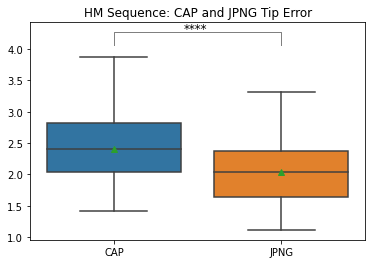

In [43]:
ax = sns.boxplot(data=[hm_cap_mean_errors,hm_jpng_mean_errors],orient='v',showmeans=True)
print('Static Experiment HM Sequence: CAP vs JPNG Tip Error')
max_y = max(np.max(hm_cap_mean_errors),np.max(hm_jpng_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('HM Sequence: CAP and JPNG Tip Error')
ax.set_xticklabels(['CAP','JPNG'])
plt.savefig('../reports/figures/static/HM-capVsJpng-meantipErr.pdf',dpi=600)
plt.show()

### 3P Sequence
Compare JPNG and CAP algorithms in the three-projection sequence

In [44]:
proj_df = agg_df[agg_df['Sequence']=='SRI_Original']

In [45]:
proj_cap_errors = proj_df[proj_df['Algorithm']=='centroid_around_peak']['Biases'].apply(pd.Series).values.ravel()

In [46]:
proj_jpng_errors = proj_df[proj_df['Algorithm']=='jpng']['Biases'].apply(pd.Series).values.ravel()

In [47]:
proj_cap_errors

array([1.98335206, 2.07144978, 1.81200858, ...,        nan,        nan,
              nan])

In [48]:
np.isnan(proj_cap_errors).sum() / len(proj_cap_errors)

0.03453409335762277

In [49]:
np.array_equal(np.isnan(proj_cap_errors),np.isnan(proj_jpng_errors))

True

In [50]:
# NaNs in our tip error are likely due to recordings for multiple coils finishing at slightly different times
# They match between the arrays, so remove them
proj_cap_errors = proj_cap_errors[~np.isnan(proj_cap_errors)]
proj_jpng_errors = proj_jpng_errors[~np.isnan(proj_jpng_errors)]

In [51]:
w, p = stats.wilcoxon(x=proj_jpng_errors,y=proj_cap_errors,alternative='less')

In [52]:
p

0.0

/home/lbiswas/miniconda3/envs/mr-track/lib/python3.8/site-packages/scipy/stats/morestats.py:1676: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Static Experiment 3P Sequence: CAP vs JPNG Tip Error Wilcoxon one-tailed


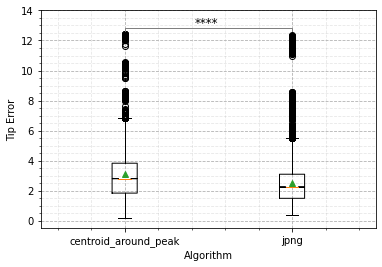

In [53]:
plot, test = disp_utils.plot_displacement_boxplot([proj_cap_errors,proj_jpng_errors], show_scatter=False,\
                                                  y_label='Tip Error',set_ymax=14, p_value=p_val_adj, alternative='greater')
print('Static Experiment 3P Sequence: CAP vs JPNG Tip Error '+ test)
plot.savefig('../reports/figures/static/3P-capVsJpng-tipErr.pdf',dpi=600)
plot.show()

#### 3P mean bias comparison
Compare JPNG and CAP algorithms in the three-projection sequence, using the mean biases from each 3d grid location - this should be an average of the biases from each catheter:

In [54]:
proj_cap_mean_errors = []
proj_jpng_mean_errors = []

In [55]:
for y in y_locs:
    for g in grid_locs:
        cap_mean = proj_df[(proj_df['Algorithm']=='centroid_around_peak') & (proj_df['Y_Loc']==y) & (proj_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        jpng_mean = proj_df[(proj_df['Algorithm']=='jpng') & (proj_df['Y_Loc']==y) & (proj_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        proj_cap_mean_errors.append(cap_mean)
        proj_jpng_mean_errors.append(jpng_mean)

In [56]:
w, p = stats.wilcoxon(x=proj_jpng_mean_errors,y=proj_cap_mean_errors,alternative='less')

In [57]:
p

1.530169880194031e-06

Static Experiment 3P Sequence: CAP vs JPNG Tip Error


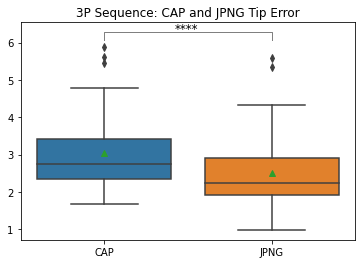

In [58]:
ax = sns.boxplot(data=[proj_cap_mean_errors,proj_jpng_mean_errors],orient='v',showmeans=True)
print('Static Experiment 3P Sequence: CAP vs JPNG Tip Error')
max_y = max(np.max(proj_cap_mean_errors),np.max(proj_jpng_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('3P Sequence: CAP and JPNG Tip Error')
ax.set_xticklabels(['CAP','JPNG'])
plt.savefig('../reports/figures/static/3P-capVsJpng-meantipErr.pdf',dpi=600)
plt.show()

## HM vs 3P
### JPNG
Compare tip errors from hadamard and three-projection sequences for JPNG algorithm.

In [59]:
jpng_df = agg_df[agg_df['Algorithm']=='jpng'].copy()

We're missing a recording from one catheter & location combination from the 3P sequence:
- Y_Loc: Y2
- Catheter: C306
- Grid_Loc: 2

To do a paired comparison, we should remove the matching recording from the HM sequence.

In [60]:
missing_match = jpng_df[(jpng_df['Y_Loc']=='Y2') & (jpng_df['Sequence']=='FH512_noDither_gradSpoiled') & \
                       (jpng_df['Catheter']=='C306') & (jpng_df['Grid_Loc']==2)].index

In [61]:
jpng_df = jpng_df.drop(missing_match)

In [62]:
jpng_df['Biases_Crop'] = jpng_df['Biases'] # Will crop this bias list to the smaller sample size

In [63]:
def check_nans(biases):
    """ Check if the only NaNs are clustered in the tail, with no non-NaNs after the first NaN
    """
    bias_nans = np.isnan(biases)
    if bias_nans.sum() == 0: # No NaNs
        return True
    first_nan_ind = np.argmax(bias_nans)
    return np.all(bias_nans[first_nan_ind:])

def crop_tails(biases):
    """ Crop everything after the first NaN
    """
    bias_nans = np.isnan(biases)
    if bias_nans.sum() == 0: # No NaNs
        return biases # don't crop
    first_nan_ind = np.argmax(bias_nans)
    return biases[0:first_nan_ind]
                              
def crop_bias_list(bias_list, yloc, gridloc, catheter, shorter_sequence, df):
    # find the combination of location and catheter from a different (shorter) sequence in the dataframe
    # and return the given bias list, shortened so that it matches the number of samples from the other sequence
    other_row = df[(df['Sequence']==shorter_sequence) & (df['Y_Loc']==yloc) & (df['Grid_Loc']==gridloc) & \
                   (df['Catheter']==catheter)]
    if len(other_row) < 1:
        print('**ERR** Target not found. Not cropping.')
        return bias_list
    if len(other_row) > 1:
        print(f'**WARN** Unexpected {len(other_row)} matches, expected 1')
    target = other_row.iloc[0]['Biases_Crop']
    if (len(target) >= len(bias_list)):
        print(f'**WARN** Target of size {len(target)} not shorter than bias list of size {len(bias_list)}. Not cropping.')
        return bias_list
    return bias_list[0:len(target)]

In [64]:
nan_tails = jpng_df.apply(lambda x: check_nans(x['Biases']), axis=1)

In [65]:
np.all(nan_tails)

True

In [66]:
jpng_df['Biases_Crop'] = jpng_df.apply(lambda x: crop_tails(x['Biases']),axis=1)

In [67]:
#crop_bias_list(jpng_df.iloc[0]['Biases'],'Y0',1,'C222','FH512_noDither_gradSpoiled',jpng_df)

In [68]:
jpng_df['Biases_Crop'] = jpng_df.apply(lambda x: x['Biases_Crop'] if x['Sequence'] != 'SRI_Original' else \
                                       crop_bias_list(x['Biases_Crop'], x['Y_Loc'], x['Grid_Loc'], \
                                                      x['Catheter'],'FH512_noDither_gradSpoiled', jpng_df), \
                                       axis=1)

In [69]:
jpng_HM_errors = jpng_df[jpng_df['Sequence']=='FH512_noDither_gradSpoiled']['Biases_Crop'].apply(pd.Series).values.ravel()

In [70]:
jpng_3P_errors = jpng_df[jpng_df['Sequence']=='SRI_Original']['Biases_Crop'].apply(pd.Series).values.ravel()

In [71]:
len(jpng_HM_errors)

26312

In [72]:
len(jpng_3P_errors)

26312

In [73]:
np.isnan(jpng_3P_errors).sum()

1016

In [74]:
np.isnan(jpng_HM_errors).sum()

1016

In [75]:
np.isnan(jpng_HM_errors).sum() / len(jpng_HM_errors)

0.038613560352690784

In [76]:
np.array_equal(np.isnan(jpng_HM_errors),np.isnan(jpng_3P_errors))

True

In [77]:
jpng_HM_errors = jpng_HM_errors[~np.isnan(jpng_HM_errors)]
jpng_3P_errors = jpng_3P_errors[~np.isnan(jpng_3P_errors)]

In [78]:
len(jpng_HM_errors)

25296

In [79]:
len(jpng_3P_errors)

25296

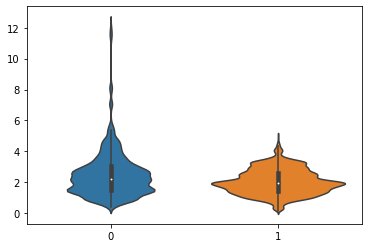

In [80]:
sns.violinplot(data=[jpng_3P_errors, jpng_HM_errors],orient='v')

Mann-Whitney U tests for independent measures: skip this and do the Wilcoxon test

In [81]:
u, p = stats.mannwhitneyu(jpng_HM_errors,jpng_3P_errors,alternative='less')

In [82]:
p

3.3494886626763926e-211

In [83]:
w, p = stats.wilcoxon(x=jpng_HM_errors,y=jpng_3P_errors,alternative='less')

In [84]:
p

3.2286080684056756e-307

Static Experiment JPNG Algorithm: 3P and HM Tip Error


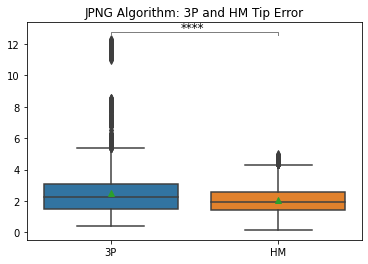

In [85]:
ax = sns.boxplot(data=[jpng_3P_errors,jpng_HM_errors],orient='v',showmeans=True)
print('Static Experiment JPNG Algorithm: 3P and HM Tip Error')
max_y = max(np.max(jpng_3P_errors),np.max(jpng_HM_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.5, star_str, ha='center', fontsize=12)
ax.set_title('JPNG Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/JPNG-3PvsHM-boxplot.pdf',dpi=600)
plt.show()

#### JPNG: compare the means 
Compare mean tip errors from hadamard and three-projection sequences for JPNG algorithm: get the means from each 3d grid location, from all catheters, using the means of the Biases_Crop columns (to ensure the same number of samples are used)

In [86]:
jpng_3P_mean_errors = []
jpng_HM_mean_errors = []
for y in y_locs:
    for g in grid_locs:
        proj_biases = jpng_df[(jpng_df['Sequence']=='SRI_Original') & (jpng_df['Y_Loc']==y) & (jpng_df['Grid_Loc']==g)]['Biases_Crop'].apply(pd.Series).values.ravel()
        hm_biases = jpng_df[(jpng_df['Sequence']=='FH512_noDither_gradSpoiled') & (jpng_df['Y_Loc']==y) & (jpng_df['Grid_Loc']==g)]['Biases_Crop'].apply(pd.Series).values.ravel()
        proj_biases = proj_biases[~np.isnan(proj_biases)]
        hm_biases = hm_biases[~np.isnan(hm_biases)]
        jpng_3P_mean_errors.append(np.mean(proj_biases))
        jpng_HM_mean_errors.append(np.mean(hm_biases))

In [87]:
w, p = stats.wilcoxon(x=jpng_HM_mean_errors,y=jpng_3P_mean_errors,alternative='less')

In [88]:
p

0.002554838909531546

In [89]:
p_val_adj

0.0125

Static Experiment JPNG Algorithm: 3P and HM Mean Tip Error


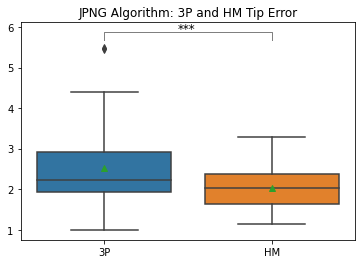

In [120]:
ax = sns.boxplot(data=[jpng_3P_mean_errors,jpng_HM_mean_errors],orient='v',showmeans=True)
print('Static Experiment JPNG Algorithm: 3P and HM Mean Tip Error')
max_y = max(np.max(jpng_3P_mean_errors),np.max(jpng_HM_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('JPNG Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/JPNG-3PvsHM-mean_boxplot.pdf',dpi=600)
plt.show()

## CAP
Compare tip errors from hadamard and three-projection sequences for the centroid-around-peak algorithm.

In [91]:
cap_df = agg_df[agg_df['Algorithm']=='centroid_around_peak'].copy()

In [92]:
missing_match = cap_df[(cap_df['Y_Loc']=='Y2') & (cap_df['Sequence']=='FH512_noDither_gradSpoiled') & \
                       (cap_df['Catheter']=='C306') & (cap_df['Grid_Loc']==2)].index

In [93]:
# drop the hm recording that doesn't have a matching 3p recording
cap_df = cap_df.drop(missing_match)

In [94]:
cap_df['Biases_Crop'] = cap_df['Biases'] # Will crop this bias list to the smaller sample size

In [95]:
nan_tails = cap_df.apply(lambda x: check_nans(x['Biases']), axis=1) # check if all the NaNs are in the tails

In [96]:
np.all(nan_tails)

True

In [97]:
cap_df['Biases_Crop'] = cap_df.apply(lambda x: crop_tails(x['Biases']),axis=1) # crop off the NaNs

In [98]:
# Match sample size between sequences
cap_df['Biases_Crop'] = cap_df.apply(lambda x: x['Biases_Crop'] if x['Sequence'] != 'SRI_Original' else \
                                       crop_bias_list(x['Biases_Crop'], x['Y_Loc'], x['Grid_Loc'], \
                                                      x['Catheter'],'FH512_noDither_gradSpoiled', cap_df), \
                                       axis=1)

In [99]:
cap_HM_errors = cap_df[cap_df['Sequence']=='FH512_noDither_gradSpoiled']['Biases_Crop'].apply(pd.Series).values.ravel()
cap_3P_errors = cap_df[cap_df['Sequence']=='SRI_Original']['Biases_Crop'].apply(pd.Series).values.ravel()

In [100]:
len(cap_HM_errors)

26312

In [101]:
len(cap_3P_errors)

26312

In [102]:
np.isnan(cap_HM_errors).sum()

1016

In [103]:
np.isnan(cap_3P_errors).sum()

1016

In [104]:
np.isnan(cap_3P_errors).sum() / len(cap_3P_errors)

0.038613560352690784

In [105]:
np.array_equal(np.isnan(cap_HM_errors),np.isnan(cap_3P_errors))

True

In [106]:
cap_HM_errors = cap_HM_errors[~np.isnan(cap_HM_errors)]
cap_3P_errors = cap_3P_errors[~np.isnan(cap_3P_errors)]

In [107]:
len(cap_HM_errors)

25296

In [108]:
len(cap_3P_errors)

25296

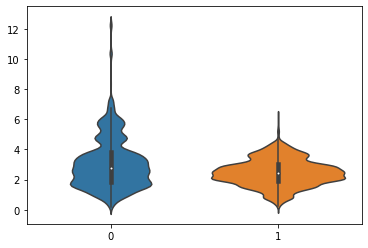

In [109]:
sns.violinplot(data=[cap_3P_errors, cap_HM_errors],orient='v')

Mann Whitney U test for independent measures: skip this and go to Wilcoxon test since our samples are now paired

In [110]:
u, p = stats.mannwhitneyu(cap_HM_errors,cap_3P_errors,alternative='less')

In [111]:
p

7.6739822179025674e-267

In [112]:
w, p = stats.wilcoxon(x=cap_HM_errors,y=cap_3P_errors,alternative='less')

In [113]:
p

0.0

Static Experiment CAP Algorithm: 3P and HM Tip Error


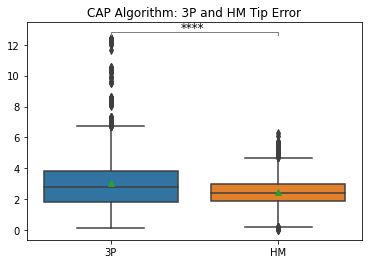

In [114]:
ax = sns.boxplot(data=[cap_3P_errors,cap_HM_errors],orient='v',showmeans=True)
print('Static Experiment CAP Algorithm: 3P and HM Tip Error')
max_y = max(np.max(cap_3P_errors),np.max(cap_HM_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.5, star_str, ha='center', fontsize=12)
ax.set_title('CAP Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/CAP-3PvsHM-boxplot.pdf',dpi=600)
plt.show()

#### CAP: compare the means 
Compare mean tip errors from hadamard and three-projection sequences for CAP algorithm: get the means from each 3d grid location, from all catheters, using the means of the Biases_Crop columns (to ensure the same number of samples are used)

In [115]:
cap_3P_mean_errors = []
cap_HM_mean_errors = []
for y in y_locs:
    for g in grid_locs:
        proj_biases = cap_df[(cap_df['Sequence']=='SRI_Original') & (cap_df['Y_Loc']==y) & (cap_df['Grid_Loc']==g)]['Biases_Crop'].apply(pd.Series).values.ravel()
        hm_biases = cap_df[(cap_df['Sequence']=='FH512_noDither_gradSpoiled') & (cap_df['Y_Loc']==y) & (cap_df['Grid_Loc']==g)]['Biases_Crop'].apply(pd.Series).values.ravel()
        proj_biases = proj_biases[~np.isnan(proj_biases)]
        hm_biases = hm_biases[~np.isnan(hm_biases)]
        cap_3P_mean_errors.append(np.mean(proj_biases))
        cap_HM_mean_errors.append(np.mean(hm_biases))

In [116]:
w, p = stats.wilcoxon(x=cap_HM_mean_errors,y=cap_3P_mean_errors,alternative='less')

In [117]:
p

0.0002634327900464859

Static Experiment CAP Algorithm: 3P and HM Mean Tip Error


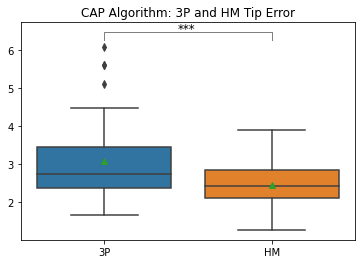

In [118]:
ax = sns.boxplot(data=[cap_3P_mean_errors,cap_HM_mean_errors],orient='v',showmeans=True)
print('Static Experiment CAP Algorithm: 3P and HM Mean Tip Error')
max_y = max(np.max(cap_3P_mean_errors),np.max(cap_HM_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('CAP Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/CAP-3PvsHM-mean_boxplot.pdf',dpi=600)
plt.show()

# HDF5 Exports
Error data has been saved to hdf5 (Hierarchical Data Format) files, one file for each sequence and algorithm combination. These can be read using your own code for further analysis, as shown in the code snippet below.

We check that we can open and read the most recent hdf5 file. The catheter error arrays are stored as datasets within this file.

Output the first dataset as an array from this file. This is a 2d array containing the tip errors for this catheter.

For each grid position:
the ground truth X coordinate, Z coordinate, bias (tip error) in mm, tip variance in mm (in that order)

So, there are 16 elements arranged like:

`[ [GT_x_pos0, GT_z_pos0, bias_pos0, variance_pos0], [GT_x_pos1, GT_z_pos1, bias_pos1, variance_pos1], ... [GT_x_pos15, GT_z_pos15, bias_pos15, variance_pos2] ]`

In [119]:
with h5py.File(h5out, 'r', libver='latest') as f:
    first_dataset = list(f.keys())[0]

    print("Looking at catheter tip errors for " + first_dataset \
          + "\n from the file: " + h5out)
    
    # Can also use h5py dataset object: ds_obj = f[a_group_key]
    # The 2d array contains the tip error for this catheter
    ds_arr = f[first_dataset][()]  # returns as a numpy array
    print(ds_arr)

Looking at catheter tip errors for static_err_FH512_noDither_gradSpoiled_jpng_trackTest-7Jan2022-C306-Y2
 from the file: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_jpng.h5
[[-3.80553565e+00 -1.87287835e+01  3.01972004e+00  1.82483396e-02
   1.78000000e+02]
 [ 2.96936945e+01 -1.86500552e+01  2.52316185e+00  6.62942355e-03
   1.75000000e+02]
 [ 6.26533407e+01 -1.88988546e+01  1.75350725e+00  1.71687016e-02
   1.75000000e+02]
 [ 9.62574016e+01 -1.85214438e+01  1.60101448e+00  3.35942592e-03
   1.75000000e+02]
 [ 9.64131762e+01  1.65016458e+01  2.20597798e+00  6.03042848e-03
   1.80000000e+02]
 [ 6.30397218e+01  1.63046923e+01  1.77427877e+00  1.30824085e-02
   1.77000000e+02]
 [ 2.93706112e+01  1.61286079e+01  2.83829928e+00  4.65173381e-02
   1.83000000e+02]
 [-3.41449462e+00  1.57894111e+01  3.22238026e+00  8.92779794e-03
   1.75000000e+02]
 [-4.17528641e+00  4.91897834e+01  1.17637438e+00  6.35044911e-03
   1.75000000e+02]
 [ 2.84294862e+01  4.92649623e+01  1.23553956e+00  